# Ablation Study

In this notebook we run an ablation study, where we take each study-trial-seed results and compute the test accuracy of the single antenna gaussian VAEs.

The full model weights from the launch are required for this notebook.

## Setup

In [2]:
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.evaluator import Evaluator
from csi_vae.jobs.job import make_dataloader

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 10,
        "figure.dpi": 300,
    },
)


settings = JobSettings()

LAUNCH_DIR = Path("../out/flat_conv_full")
WEIGHTS_DIR = Path("../weights")
ABLATION_STUDY_DIR = LAUNCH_DIR / "ablation_study"
PLOTS_DIR = LAUNCH_DIR / "plots"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ABLATION_STUDY_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)

## Load Studies

We need the studies info to get the model configuration, i.e. the convolutional layer specification that was used.

In [3]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

## Run Ablation Study

In [ ]:
def load_gaussians(model_report: dict, weights_path: Path) -> list[vae.SingleAntenna]:
    """Load the best model from the given model report and weights path.

    Arguments:
        model_report: A dictionary containing the model information.
        weights_path: Path to the model weights file.

    Returns:
        A list of loaded SingleAntenna models.

    """
    gaussians = [
        vae.SingleAntenna(
            settings.window_size,
            settings.n_subcarriers,
            model_report["n_gaussians"],
            vae.CONV_SPECS[model_report["params"]["conv_layers_spec"]],
        ).to(DEVICE)
        for _ in range(settings.n_antennas)
    ]
    delayed_fusion = fusion.Delayed(
        gaussians,
        model_report["n_gaussians"],
        settings.n_activities,
        model_report["params"]["n_fusion_layers"],
        model_report["params"]["fusion_dropout"],
    ).to(DEVICE)
    delayed_fusion.load_state_dict(torch.load(weights_path))

    return gaussians


def train_and_eval_antenna(
    antenna_idx: int,
    gaussian: vae.SingleAntenna,
    n_gaussians: int,
    model_report: dict,
    seed: int,
) -> float:
    """Train and evaluate a single antenna model.

    Arguments:
        antenna_idx: Index of the antenna to train and evaluate.
        gaussian: The SingleAntenna model to train and evaluate.
        n_gaussians: The number of Gaussian components in the model.
        model_report: A dictionary containing the model information.
        seed: Random seed for reproducibility.

    Returns:
        The accuracy of the model on the test dataset.

    """
    antenna_train_ds = dataset.SingleAntenna(train_ds, antenna_idx)
    antenna_val_ds = dataset.SingleAntenna(val_ds, antenna_idx)
    antenna_test_ds = dataset.SingleAntenna(test_ds, antenna_idx)

    train_dl = make_dataloader(antenna_train_ds, settings.batch_size, shuffle=True, seed=int(seed))
    val_dl = make_dataloader(antenna_val_ds, settings.batch_size, shuffle=False, seed=int(seed))
    test_dl = make_dataloader(antenna_test_ds, settings.batch_size, shuffle=False, seed=int(seed))

    delayed_fusion = fusion.Delayed(
        [gaussian],
        n_gaussians,
        settings.n_activities,
        model_report["params"]["n_fusion_layers"],
        model_report["params"]["fusion_dropout"],
    ).to(DEVICE)

    trainer = fusion.Trainer(
        delayed_fusion,
        train_dl,
        val_dl,
        fusion.TrainerParams(
            model_report["params"]["lr"],
            settings.early_stop_patience,
            settings.early_stop_warmup_epochs,
        ),
        DEVICE,
    )
    trainer.train(settings.n_epochs)

    return Evaluator(delayed_fusion, test_dl, DEVICE).evaluate()

The following code is a mess, and also saves the ablation studies in a weird format

In [ ]:
for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    study_results = {}

    for _, trial in completed.iterrows():
        trial_results = {}

        for seed in trial["user_attrs_accuracies"]:
            seed_results = []

            model_report = {
                "n_gaussians": i + 1,
                "params": {
                    "conv_layers_spec": trial["params_conv_layers_spec"],
                    "n_fusion_layers": trial["params_n_fusion_layers"],
                    "fusion_dropout": trial["params_fusion_dropout"],
                    "lr": trial["params_lr"],
                },
            }
            weights_path = WEIGHTS_DIR / f"l{i + 1}" / f"t{trial['number']}" / f"s{seed}" / "delayed_fusion.pt"
            gaussians = load_gaussians(model_report, weights_path)

            seed_results = [0.0] * settings.n_antennas
            with ThreadPoolExecutor(max_workers=settings.n_antennas) as executor:
                futures = {
                    executor.submit(
                        train_and_eval_antenna,
                        antenna_idx,
                        gaussians[antenna_idx],
                        i + 1,
                        model_report,
                        seed,
                    ): antenna_idx
                    for antenna_idx in range(settings.n_antennas)
                }

                for future in as_completed(futures):
                    antenna_idx = futures[future]
                    seed_results[antenna_idx] = future.result()

            trial_results[str(seed)] = seed_results
            print(f"Completed seed {seed} of trial {trial['number']} with accuracies: {seed_results}")

        study_results[str(trial["number"])] = trial_results

    study_results = pd.DataFrame(study_results)
    study_results.to_csv(ABLATION_STUDY_DIR / f"l{i + 1}.csv", index=False)

## Plot Results

In [6]:
ablation_results_files = sorted([result.name for result in ABLATION_STUDY_DIR.iterdir() if result.is_file()])

study_results_per_file = []
max_trials = 0
max_seeds = 0

for result_file in ablation_results_files:
    full_df = pd.read_csv(ABLATION_STUDY_DIR / result_file)

    study_results = []
    for col in range(full_df.shape[1]):
        seed_results = full_df.iloc[:, col].dropna().apply(json.loads)
        trial_results = np.asarray(seed_results.tolist(), dtype=float).T  # (n_antennas, n_seeds)

        study_results.append(trial_results)
        max_seeds = max(max_seeds, trial_results.shape[1])

    max_trials = max(max_trials, len(study_results))
    study_results_per_file.append(study_results)

ablation_results = np.full(
    (len(study_results_per_file), max_trials, settings.n_antennas, max_seeds),
    np.nan,
    dtype=float,
)

for study_idx, study_results in enumerate(study_results_per_file):
    for trial_idx, trial_results in enumerate(study_results):
        n_seeds = trial_results.shape[1]
        if n_seeds > 0:
            ablation_results[study_idx, trial_idx, :, :n_seeds] = trial_results

print(ablation_results.shape)  # (n_studies, max_trials, n_antennas, max_seeds)

(4, 100, 4, 10)


In [7]:
best_models_per_study: list[dict] = []

for i, study in enumerate(studies[:4]):
    completed = study[study["state"] == "COMPLETE"].copy().reset_index(drop=True)
    study_info = {
        "n_gaussians": i + 1,
        "trial_number": 0,
        "trial_value": 0,
        "fusion_accuracies": [],
        "antennas_accuracies": [],
    }
    study_best_trial = 0
    study_best_trial_value = 0.0

    for j, trial in completed.iterrows():
        accuracies_per_seed = trial["user_attrs_accuracies"]

        best_seed = max(accuracies_per_seed, key=accuracies_per_seed.get)
        best_accuracy = float(accuracies_per_seed[str(best_seed)])

        if trial["value"] > study_info["trial_value"]:
            study_info = {
                "n_gaussians": i + 1,
                "trial_number": trial["number"],
                "trial_value": trial["value"],
                "fusion_accuracies": accuracies_per_seed,
                "antennas_accuracies": ablation_results[i, j].tolist(),
            }

    best_models_per_study.append(study_info)

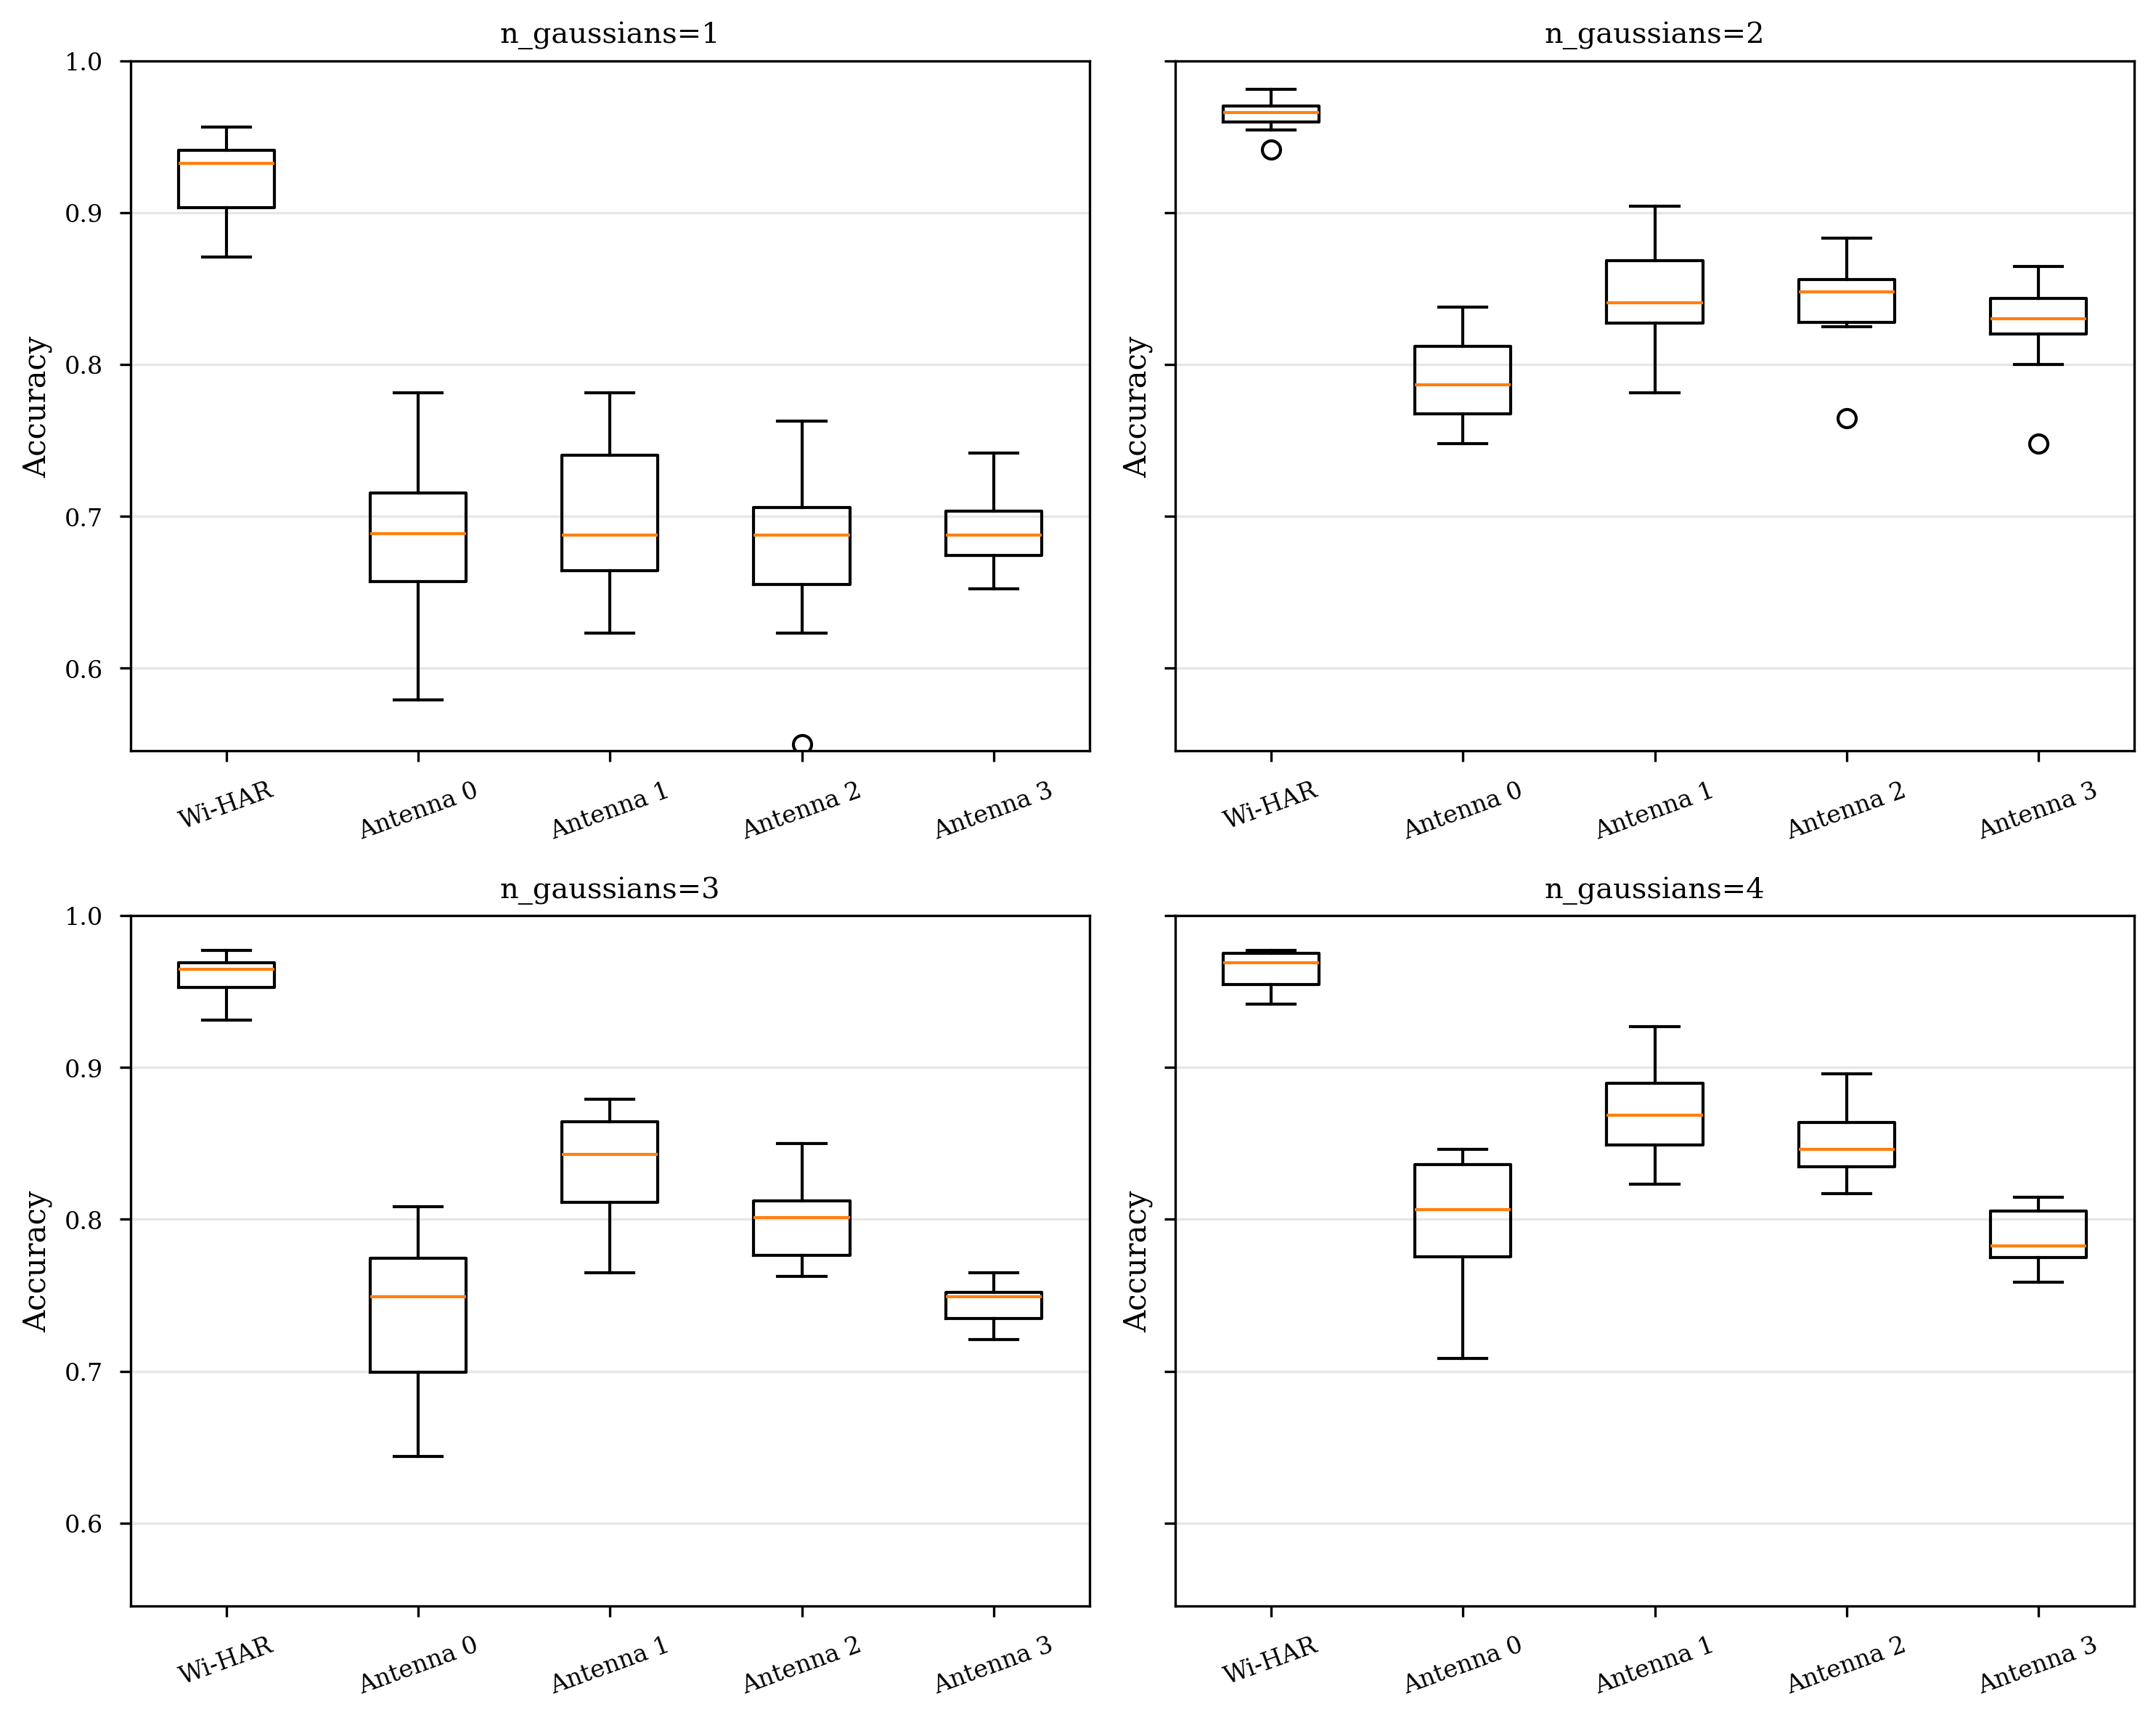

In [10]:
# Build plot payload from best_models_per_study and compute shared y-range
plot_payload = []
global_min, global_max = np.inf, -np.inf

for study_info in best_models_per_study:
    fusion_acc = np.asarray(list(study_info["fusion_accuracies"].values()), dtype=float)
    antenna_acc = np.asarray(study_info["antennas_accuracies"], dtype=float)  # (n_antennas, n_seeds)

    if fusion_acc.size == 0 or antenna_acc.size == 0:
        continue

    if antenna_acc.ndim == 1:
        antenna_acc = antenna_acc[None, :]

    data = [fusion_acc] + [antenna_acc[a, ~np.isnan(antenna_acc[a])] for a in range(antenna_acc.shape[0])]
    labels = ["Wi-HAR"] + [f"Antenna {a}" for a in range(antenna_acc.shape[0])]

    all_vals = np.concatenate([d.ravel() for d in data if d.size > 0])
    if all_vals.size == 0:
        continue

    global_min = min(global_min, float(np.min(all_vals)))
    global_max = max(global_max, float(np.max(all_vals)))

    plot_payload.append((study_info, data, labels))

if not plot_payload:
    print("No data to plot from best_models_per_study.")
else:
    ymax = 1.0
    pad = 0.01 * (ymax - global_min) if ymax > global_min else 0.01
    ymin = max(0.0, global_min - pad)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
    axes = axes.ravel()

    for ax, (study_info, data, labels) in zip(axes, plot_payload):
        ax.boxplot(data, tick_labels=labels)
        ax.set_title(f"n_gaussians={study_info['n_gaussians']}")
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel("Accuracy")
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=20)

    for ax in axes[len(plot_payload):]:
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "ablation_study_2x2.pdf")
    plt.show()
